# AI-Enhanced Intrusion Detection System
## Complete Training Notebook

**Instructions:**
1. Copy your primus11 dataset (`NSL_KDD_Train.csv`) to the `dataset/` folder
2. Run each cell one by one (Shift + Enter)
3. Best model will be saved to `models/best_model.pkl`

In [1]:
import sys
print(sys.executable)

C:\Users\HP\AppData\Local\Programs\Python\Python310\python.exe


In [2]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost flask

In [3]:
import sys
print(sys.executable)

C:\Users\HP\AppData\Local\Programs\Python\Python310\python.exe


In [4]:
import sys
!{sys.executable} -m pip install xgboost


[notice] A new release of pip available: 22.2.1 -> 26.1.2
[notice] To update, run: C:\Users\HP\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


In [5]:
import xgboost as xgb
print(xgb.__version__)

3.2.0


In [6]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
from sklearn.utils.class_weight import compute_sample_weight

try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except Exception as e:
    XGBOOST_AVAILABLE = False
    xgb = None
    print(f"?? XGBoost not available: {e}")

RANDOM_STATE = 42
CLASS_NAMES = ['Normal', 'DoS', 'Probe', 'R2L', 'U2R']
ATTACK_NAMES = {0: 'Normal', 1: 'DoS', 2: 'Probe', 3: 'R2L', 4: 'U2R'}

print("=" * 60)
print("??? SMARTBRIDGE CAPSTONE PROJECT")
print("AI-Enhanced Intrusion Detection System")
print("=" * 60)
print("? Libraries imported successfully!")


??? SMARTBRIDGE CAPSTONE PROJECT
AI-Enhanced Intrusion Detection System
? Libraries imported successfully!


In [7]:
import os

path = r"C:\Users\HP\Documents\AI_Enhance\dataset"
print(os.listdir(path))

['index.html', 'KDDTest-21.arff', 'KDDTest-21.txt', 'KDDTest.arff', 'KDDTest.txt', 'KDDTest1.jpg', 'KDDTrain.arff', 'KDDTrain.txt', 'KDDTrain1.jpg', 'KDDTrain_20Percent.arff', 'KDDTrain_20Percent.txt']


In [8]:

# ==========================================
# CELL 3: DOWNLOAD / LOAD NSL-KDD DATASET
# ==========================================
import os
import urllib.request
import pandas as pd

print("=" * 60)
print("?? NSL-KDD DATASET LOADER")
print("=" * 60)

os.makedirs('dataset', exist_ok=True)
download_path = 'dataset/KDDTrain+.txt'
GITHUB_URL = "https://github.com/jmnwong/NSL-KDD-Dataset/raw/master/KDDTrain%2B.txt"

if not os.path.exists(download_path):
    print("\n?? Downloading dataset from GitHub...")
    print("? Please wait 1-2 minutes...")
    urllib.request.urlretrieve(GITHUB_URL, download_path)
else:
    print(f"\n? Using existing file: {download_path}")

print(f"?? Size: {os.path.getsize(download_path) / (1024*1024):.2f} MB")

# NSL-KDD has 41 feature columns + label + difficulty_level.
col_names = ["duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
             "wrong_fragment","urgent","hot","num_failed_logins","logged_in","num_compromised",
             "root_shell","su_attempted","num_root","num_file_creations","num_shells",
             "num_access_files","num_outbound_cmds","is_host_login","is_guest_login","count",
             "srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate",
             "same_srv_rate","diff_srv_rate","srv_diff_host_rate","dst_host_count",
             "dst_host_srv_count","dst_host_same_srv_rate","dst_host_diff_srv_rate",
             "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate","dst_host_serror_rate",
             "dst_host_srv_serror_rate","dst_host_rerror_rate","dst_host_srv_rerror_rate",
             "label", "difficulty_level"]

df = pd.read_csv(download_path, names=col_names)
df.drop(columns=['difficulty_level'], inplace=True)

print(f"? Dataset loaded successfully!")
print(f"?? Shape: {df.shape[0]} rows ? {df.shape[1]} columns")
print(f"?? Columns: {list(df.columns)}")
print("\n?? First 5 rows:")
display(df.head())

df.to_csv('dataset/NSL_KDD_Train.csv', index=False)
print("\n?? Saved clean CSV as: dataset/NSL_KDD_Train.csv")


?? NSL-KDD DATASET LOADER

? Using existing file: dataset/KDDTrain+.txt
?? Size: 18.22 MB
? Dataset loaded successfully!
?? Shape: 125973 rows ? 42 columns
?? Columns: ['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label']

?? First 5 rows:


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal



?? Saved clean CSV as: dataset/NSL_KDD_Train.csv


In [9]:
# Verify cell - Cell 3 nantar run kara
try:
    print(f"✅ df exists: {df.shape}")
    print(f"Columns: {list(df.columns)}")
except NameError:
    print("❌ df NOT found! Cell 3 fail zala.")

✅ df exists: (125973, 42)
Columns: ['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label']


In [10]:
print("=" * 60)
print("🔍 CHECKING MISSING VALUES")
print("=" * 60)

missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing Count': missing.values,
    'Missing %': missing_percent.values
})

if missing.sum() > 0:
    print(missing_df[missing_df['Missing Count'] > 0])
else:
    print("✅ No missing values found!")

# Handle infinite values
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)
print(f"\n✅ After cleaning: {df.shape}")

🔍 CHECKING MISSING VALUES
✅ No missing values found!

✅ After cleaning: (125973, 42)


In [11]:
print("=" * 60)
print("🔍 CHECKING DUPLICATES")
print("=" * 60)

duplicates = df.duplicated().sum()
print(f"Duplicate rows found: {duplicates}")

df.drop_duplicates(inplace=True)
print(f"✅ After removing duplicates: {df.shape}")
print(f"✅ Final dataset ready for processing!")

🔍 CHECKING DUPLICATES
Duplicate rows found: 0
✅ After removing duplicates: (125973, 42)
✅ Final dataset ready for processing!


📊 EXPLORATORY DATA ANALYSIS

Label distribution:
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: label, dtype: int64


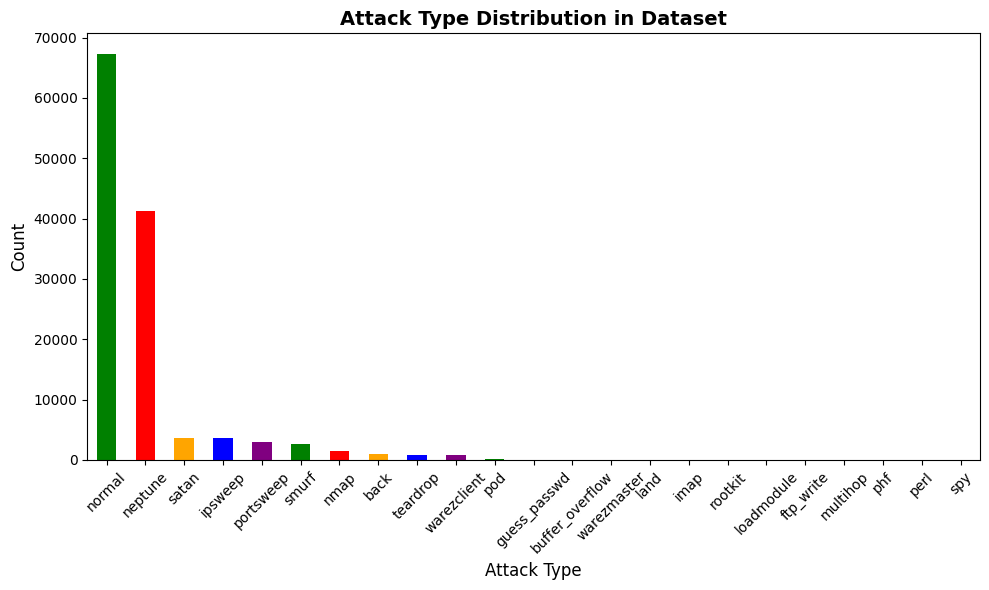

📊 Chart saved: label_distribution.png


In [12]:
print("=" * 60)
print("📊 EXPLORATORY DATA ANALYSIS")
print("=" * 60)

# Handle label column name
if 'class' in df.columns:
    df.rename(columns={'class': 'label'}, inplace=True)
    print("✅ Renamed 'class' to 'label'")

print(f"\nLabel distribution:\n{df['label'].value_counts()}")

# Plot
plt.figure(figsize=(10, 6))
df['label'].value_counts().plot(kind='bar', color=['green', 'red', 'orange', 'blue', 'purple'])
plt.title('Attack Type Distribution in Dataset', fontsize=14, fontweight='bold')
plt.xlabel('Attack Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('label_distribution.png', dpi=150)
plt.show()
print("📊 Chart saved: label_distribution.png")

In [13]:

# ==========================================
# CELL 7: IDENTIFY CATEGORICAL FEATURES
# ==========================================
print("=" * 60)
print("?? CATEGORICAL FEATURE CHECK")
print("=" * 60)

categorical_cols = ['protocol_type', 'service', 'flag']
categorical_cols = [col for col in categorical_cols if col in df.columns]

print("\n?? Data Types:")
print(df.dtypes)
print(f"\n?? Categorical columns: {categorical_cols}")
print("? Encoding will be fitted on training data only to avoid data leakage.")


?? CATEGORICAL FEATURE CHECK

?? Data Types:
duration                         int64
protocol_type                   object
service                         object
flag                            object
src_bytes                        int64
dst_bytes                        int64
land                             int64
wrong_fragment                   int64
urgent                           int64
hot                              int64
num_failed_logins                int64
logged_in                        int64
num_compromised                  int64
root_shell                       int64
su_attempted                     int64
num_root                         int64
num_file_creations               int64
num_shells                       int64
num_access_files                 int64
num_outbound_cmds                int64
is_host_login                    int64
is_guest_login                   int64
count                            int64
srv_count                        int64
serror_rate        

In [14]:

# ==========================================
# CELL 8: MAP LABELS TO 5 ATTACK CATEGORIES
# ==========================================
print("=" * 60)
print("?? MAPPING LABELS TO 5 ATTACK CATEGORIES")
print("=" * 60)

print("\n?? Unique raw labels in dataset:")
print(df['label'].value_counts())

attack_mapping = {
    'normal': 0,
    'neptune': 1, 'back': 1, 'land': 1, 'pod': 1, 'smurf': 1, 'teardrop': 1,
    'apache2': 1, 'udpstorm': 1, 'processtable': 1, 'mailbomb': 1,
    'satan': 2, 'ipsweep': 2, 'nmap': 2, 'portsweep': 2, 'mscan': 2, 'saint': 2,
    'guess_passwd': 3, 'ftp_write': 3, 'imap': 3, 'phf': 3, 'multihop': 3,
    'warezmaster': 3, 'warezclient': 3, 'spy': 3, 'xlock': 3, 'xsnoop': 3,
    'snmpguess': 3, 'snmpgetattack': 3, 'httptunnel': 3, 'sendmail': 3, 'named': 3,
    'buffer_overflow': 4, 'loadmodule': 4, 'rootkit': 4, 'perl': 4,
    'sqlattack': 4, 'xterm': 4, 'ps': 4
}

raw_labels = df['label'].astype(str).str.strip().str.lower()
unmapped = sorted(set(raw_labels) - set(attack_mapping))
if unmapped:
    print(f"?? Unmapped labels found and treated as Normal: {unmapped}")

df['label'] = raw_labels.map(attack_mapping).fillna(0).astype(int)

print("\n? Label mapping complete!")
for idx, name in enumerate(CLASS_NAMES):
    print(f"   {idx} = {name}")

print("\n?? Final label distribution:")
print(df['label'].value_counts().sort_index().rename(index=ATTACK_NAMES))


?? MAPPING LABELS TO 5 ATTACK CATEGORIES

?? Unique raw labels in dataset:
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: label, dtype: int64

? Label mapping complete!
   0 = Normal
   1 = DoS
   2 = Probe
   3 = R2L
   4 = U2R

?? Final label distribution:
Normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: label, dtype: int64


In [15]:

# ==========================================
# CELL 9: TRAIN/TEST SPLIT + LEAKAGE-FREE PREPROCESSING
# ==========================================
print("=" * 60)
print("?? SPLIT + PREPROCESSING")
print("=" * 60)

X = df.drop('label', axis=1).copy()
y = df['label'].copy()
features = list(X.columns)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Fit categorical encoder only on training rows. Unknown values at prediction time become -1.
cat_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train_enc = X_train_raw.copy()
X_test_enc = X_test_raw.copy()

if categorical_cols:
    X_train_enc[categorical_cols] = cat_encoder.fit_transform(X_train_raw[categorical_cols].astype(str))
    X_test_enc[categorical_cols] = cat_encoder.transform(X_test_raw[categorical_cols].astype(str))
else:
    cat_encoder = None

# Numeric cleanup fitted on training data only.
for col in features:
    X_train_enc[col] = pd.to_numeric(X_train_enc[col], errors='coerce')
    X_test_enc[col] = pd.to_numeric(X_test_enc[col], errors='coerce')

numeric_medians = X_train_enc.median(numeric_only=True).to_dict()
X_train_enc = X_train_enc.fillna(numeric_medians)
X_test_enc = X_test_enc.fillna(numeric_medians)

# Scale after split to avoid train/test leakage.
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train_enc), columns=features, index=X_train_enc.index)
X_test = pd.DataFrame(scaler.transform(X_test_enc), columns=features, index=X_test_enc.index)

sample_weight = compute_sample_weight(class_weight='balanced', y=y_train)

print(f"?? Training set: {X_train.shape}")
print(f"?? Testing set : {X_test.shape}")
print(f"?? Training labels: {y_train.value_counts().sort_index().to_dict()}")
print(f"?? Testing labels : {y_test.value_counts().sort_index().to_dict()}")
print("? Encoders and scaler fitted on training data only.")


?? SPLIT + PREPROCESSING
?? Training set: (100778, 41)
?? Testing set : (25195, 41)
?? Training labels: {0: 53874, 1: 36741, 2: 9325, 3: 796, 4: 42}
?? Testing labels : {0: 13469, 1: 9186, 2: 2331, 3: 199, 4: 10}
? Encoders and scaler fitted on training data only.


In [16]:

# ==========================================
# CELL 10: METRIC HELPERS
# ==========================================
print("=" * 60)
print("?? METRIC HELPERS")
print("=" * 60)

def evaluate_model(model, model_name, X_train, y_train, X_test, y_test):
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    metrics = {
        'Train Accuracy': accuracy_score(y_train, train_pred),
        'Accuracy': accuracy_score(y_test, test_pred),
        'Precision': precision_score(y_test, test_pred, average='weighted', zero_division=0),
        'Recall': recall_score(y_test, test_pred, average='weighted', zero_division=0),
        'F1': f1_score(y_test, test_pred, average='weighted', zero_division=0),
    }
    metrics['Overfit Gap'] = metrics['Train Accuracy'] - metrics['Accuracy']

    print(f"Train Accuracy: {metrics['Train Accuracy']:.4f}")
    print(f"Test Accuracy : {metrics['Accuracy']:.4f}")
    print(f"Precision     : {metrics['Precision']:.4f}")
    print(f"Recall        : {metrics['Recall']:.4f}")
    print(f"F1 Score      : {metrics['F1']:.4f}")
    print(f"Overfit Gap   : {metrics['Overfit Gap']:.4f}")
    if metrics['Overfit Gap'] > 0.05:
        print("?? Possible overfitting: train accuracy is much higher than test accuracy.")
    elif metrics['Accuracy'] < 0.80 and metrics['Train Accuracy'] < 0.85:
        print("?? Possible underfitting: both train and test accuracy are low.")
    else:
        print("? Train/test gap looks acceptable.")
    return metrics

print("? Helper ready.")


?? METRIC HELPERS
? Helper ready.


In [17]:

print("=" * 60)
print("?? TRAINING DECISION TREE")
print("=" * 60)

import time
start = time.time()

dt_model = DecisionTreeClassifier(
    max_depth=12,
    min_samples_split=40,
    min_samples_leaf=20,
    class_weight='balanced',
    random_state=RANDOM_STATE
)

dt_model.fit(X_train, y_train)
dt_time = time.time() - start

dt_metrics = evaluate_model(dt_model, 'Decision Tree', X_train, y_train, X_test, y_test)
dt_metrics['Time'] = dt_time

dt_acc = dt_metrics['Accuracy']
dt_prec = dt_metrics['Precision']
dt_rec = dt_metrics['Recall']
dt_f1 = dt_metrics['F1']
print(f"Training Time: {dt_time:.2f} sec")


?? TRAINING DECISION TREE
Train Accuracy: 0.9805
Test Accuracy : 0.9802
Precision     : 0.9885
Recall        : 0.9802
F1 Score      : 0.9831
Overfit Gap   : 0.0003
? Train/test gap looks acceptable.
Training Time: 0.89 sec


In [18]:

print("=" * 60)
print("?? TRAINING RANDOM FOREST")
print("=" * 60)

start = time.time()

rf_model = RandomForestClassifier(
    n_estimators=250,
    max_depth=14,
    min_samples_split=30,
    min_samples_leaf=10,
    max_features='sqrt',
    class_weight='balanced_subsample',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
rf_time = time.time() - start

rf_metrics = evaluate_model(rf_model, 'Random Forest', X_train, y_train, X_test, y_test)
rf_metrics['Time'] = rf_time

rf_acc = rf_metrics['Accuracy']
rf_prec = rf_metrics['Precision']
rf_rec = rf_metrics['Recall']
rf_f1 = rf_metrics['F1']
print(f"Training Time: {rf_time:.2f} sec")


?? TRAINING RANDOM FOREST
Train Accuracy: 0.9976
Test Accuracy : 0.9969
Precision     : 0.9971
Recall        : 0.9969
F1 Score      : 0.9970
Overfit Gap   : 0.0007
? Train/test gap looks acceptable.
Training Time: 17.18 sec


In [19]:

print("=" * 60)
print("? TRAINING XGBOOST")
print("=" * 60)

if XGBOOST_AVAILABLE:
    start = time.time()

    xgb_model = xgb.XGBClassifier(
        n_estimators=250,
        max_depth=5,
        learning_rate=0.05,
        min_child_weight=5,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.1,
        reg_lambda=2.0,
        objective='multi:softprob',
        eval_metric='mlogloss',
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    xgb_model.fit(X_train, y_train, sample_weight=sample_weight)
    xgb_time = time.time() - start

    xgb_metrics = evaluate_model(xgb_model, 'XGBoost', X_train, y_train, X_test, y_test)
    xgb_metrics['Time'] = xgb_time

    xgb_acc = xgb_metrics['Accuracy']
    xgb_prec = xgb_metrics['Precision']
    xgb_rec = xgb_metrics['Recall']
    xgb_f1 = xgb_metrics['F1']
    print(f"Training Time: {xgb_time:.2f} sec")
else:
    print("?? Skipping XGBoost because the package is not installed.")
    xgb_model = None
    xgb_time = 0
    xgb_metrics = None
    xgb_acc = xgb_prec = xgb_rec = xgb_f1 = 0


? TRAINING XGBOOST
Train Accuracy: 0.9989
Test Accuracy : 0.9983
Precision     : 0.9984
Recall        : 0.9983
F1 Score      : 0.9984
Overfit Gap   : 0.0005
? Train/test gap looks acceptable.
Training Time: 20.99 sec


?? MODEL COMPARISON
               Train Accuracy  Accuracy  Precision  Recall      F1  Overfit Gap     Time
Decision Tree          0.9805    0.9802     0.9885  0.9802  0.9831       0.0003   0.8905
Random Forest          0.9976    0.9969     0.9971  0.9969  0.9970       0.0007  17.1828
XGBoost                0.9989    0.9983     0.9984  0.9983  0.9984       0.0005  20.9912


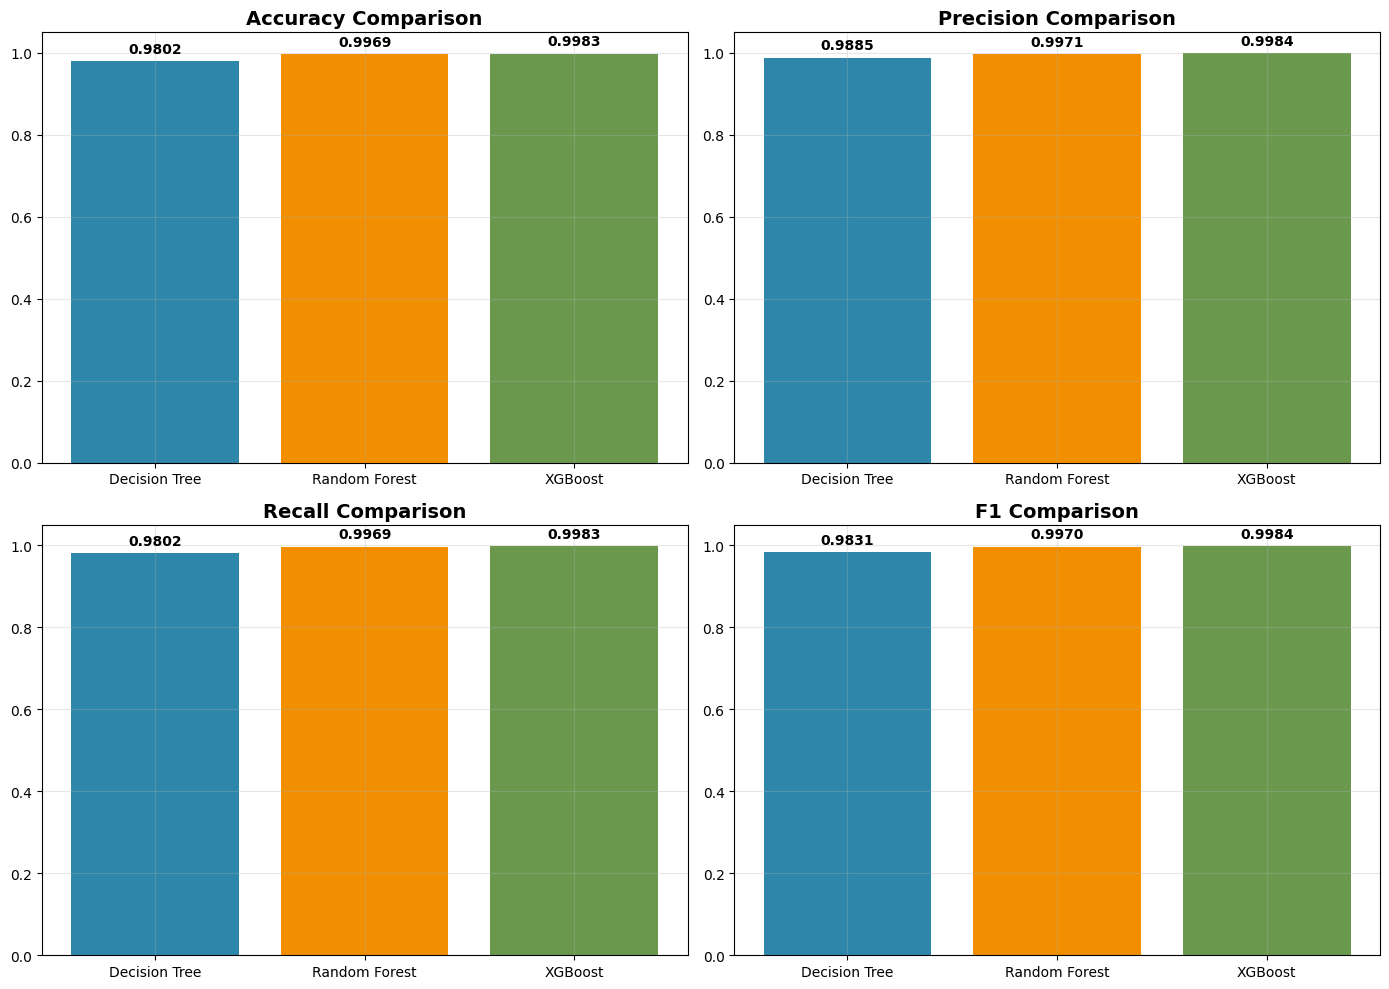

?? Chart saved: model_comparison.png


In [20]:

print("=" * 60)
print("?? MODEL COMPARISON")
print("=" * 60)

results = {
    'Decision Tree': dt_metrics,
    'Random Forest': rf_metrics,
}
if xgb_metrics is not None:
    results['XGBoost'] = xgb_metrics

comparison_df = pd.DataFrame(results).T
cols = ['Train Accuracy', 'Accuracy', 'Precision', 'Recall', 'F1', 'Overfit Gap', 'Time']
comparison_df = comparison_df[cols]
print(comparison_df.round(4).to_string())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1']
colors = ['#2E86AB', '#F18F01', '#6A994E'][:len(comparison_df)]

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx//2, idx%2]
    bars = ax.bar(comparison_df.index, comparison_df[metric], color=colors)
    ax.set_title(f'{metric} Comparison', fontsize=14, fontweight='bold')
    ax.set_ylim(0, 1.05)
    for bar, val in zip(bars, comparison_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, min(val + 0.02, 1.02),
                f'{val:.4f}', ha='center', fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()
print("?? Chart saved: model_comparison.png")


In [21]:

print("=" * 60)
print("?? AUTO BEST MODEL SELECTION")
print("=" * 60)

# Prefer high F1, but penalize models with a large train/test accuracy gap.
selection_scores = {
    name: metrics['F1'] - max(metrics['Overfit Gap'] - 0.03, 0)
    for name, metrics in results.items()
}

best_model_name = max(selection_scores, key=selection_scores.get)
best_f1 = results[best_model_name]['F1']

model_lookup = {
    'Decision Tree': dt_model,
    'Random Forest': rf_model,
    'XGBoost': xgb_model
}
best_model = model_lookup[best_model_name]

print(f"?? BEST MODEL: {best_model_name}")
print(f"?? F1 Score: {best_f1:.4f}")
print(f"?? Accuracy: {results[best_model_name]['Accuracy']:.4f}")
print(f"?? Overfit Gap: {results[best_model_name]['Overfit Gap']:.4f}")
print(f"?? Training Time: {results[best_model_name]['Time']:.2f} seconds")
print("\n? Selected using F1 score with overfitting penalty.")


?? AUTO BEST MODEL SELECTION
?? BEST MODEL: XGBoost
?? F1 Score: 0.9984
?? Accuracy: 0.9983
?? Overfit Gap: 0.0005
?? Training Time: 20.99 seconds

? Selected using F1 score with overfitting penalty.


?? CONFUSION MATRIX


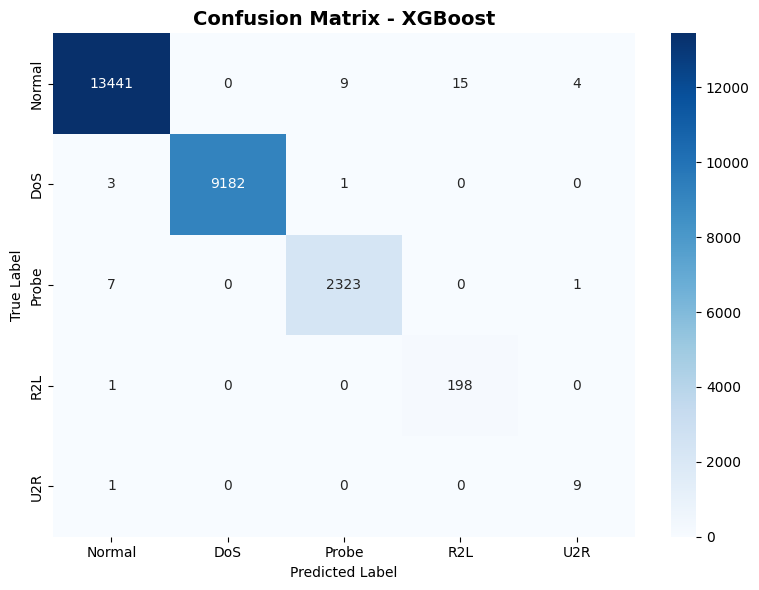


?? Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     13469
         DoS       1.00      1.00      1.00      9186
       Probe       1.00      1.00      1.00      2331
         R2L       0.93      0.99      0.96       199
         U2R       0.64      0.90      0.75        10

    accuracy                           1.00     25195
   macro avg       0.91      0.98      0.94     25195
weighted avg       1.00      1.00      1.00     25195



In [22]:

print("=" * 60)
print("?? CONFUSION MATRIX")
print("=" * 60)

y_pred_best = best_model.predict(X_test)
labels = list(range(len(CLASS_NAMES)))
cm = confusion_matrix(y_test, y_pred_best, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES)
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

print("\n?? Classification Report:")
print(classification_report(y_test, y_pred_best,
                            labels=labels,
                            target_names=CLASS_NAMES,
                            zero_division=0))


In [23]:

print("=" * 60)
print("?? SAVING BEST MODEL")
print("=" * 60)

os.makedirs('models', exist_ok=True)

model_data = {
    'model': best_model,
    'model_name': best_model_name,
    'scaler': scaler,
    'cat_encoder': cat_encoder,
    'categorical_cols': categorical_cols,
    'numeric_medians': numeric_medians,
    'features': features,
    'class_names': CLASS_NAMES,
    'attack_names': ATTACK_NAMES,
    'accuracy': results[best_model_name]['Accuracy'],
    'f1_score': results[best_model_name]['F1'],
    'overfit_gap': results[best_model_name]['Overfit Gap']
}

with open('models/best_model.pkl', 'wb') as f:
    pickle.dump(model_data, f)

with open('models/training_report.txt', 'w', encoding='utf-8') as f:
    f.write("=" * 60 + "\n")
    f.write("SMARTBRIDGE CAPSTONE PROJECT\n")
    f.write("AI-Enhanced Intrusion Detection System\n")
    f.write("Training Report\n")
    f.write("=" * 60 + "\n\n")
    f.write(f"Best Model: {best_model_name}\n")
    f.write(f"Accuracy: {results[best_model_name]['Accuracy']:.4f}\n")
    f.write(f"F1 Score: {results[best_model_name]['F1']:.4f}\n")
    f.write(f"Overfit Gap: {results[best_model_name]['Overfit Gap']:.4f}\n\n")
    f.write("All Models:\n")
    f.write(comparison_df.round(4).to_string())
    f.write("\n")

file_size = os.path.getsize('models/best_model.pkl') / (1024*1024)
print("? Model saved: models/best_model.pkl")
print(f"?? File size: {file_size:.2f} MB")
print(f"?? Model: {best_model_name}")
print(f"?? F1 Score: {best_f1:.4f}")
print(f"?? Overfit Gap: {results[best_model_name]['Overfit Gap']:.4f}")


?? SAVING BEST MODEL
? Model saved: models/best_model.pkl
?? File size: 2.06 MB
?? Model: XGBoost
?? F1 Score: 0.9984
?? Overfit Gap: 0.0005


In [24]:

print("=" * 60)
print("? VERIFYING SAVED MODEL")
print("=" * 60)

with open('models/best_model.pkl', 'rb') as f:
    loaded = pickle.load(f)

print("? Model loaded successfully!")
print(f"?? Model type: {type(loaded['model']).__name__}")
print(f"?? Model name: {loaded['model_name']}")
print(f"?? Features: {len(loaded['features'])}")
print(f"?? Accuracy: {loaded['accuracy']:.4f}")
print(f"?? F1 Score: {loaded['f1_score']:.4f}")
print(f"?? Overfit Gap: {loaded['overfit_gap']:.4f}")
print("\n?? Model is ready for prediction!")


? VERIFYING SAVED MODEL
? Model loaded successfully!
?? Model type: XGBClassifier
?? Model name: XGBoost
?? Features: 41
?? Accuracy: 0.9983
?? F1 Score: 0.9984
?? Overfit Gap: 0.0005

?? Model is ready for prediction!


In [25]:

print("=" * 60)
print("?? TEST PREDICTION")
print("=" * 60)

sample = X_test.iloc[0:1]
true_label = int(y_test.iloc[0])

prediction = int(loaded['model'].predict(sample)[0])
proba = loaded['model'].predict_proba(sample)[0] if hasattr(loaded['model'], 'predict_proba') else np.zeros(len(loaded['class_names']))

attack_names = loaded['attack_names']
predicted = attack_names.get(prediction, 'Unknown')
confidence = float(np.max(proba)) * 100 if len(proba) else 0

print(f"?? Predicted: {predicted}")
print(f"?? Confidence: {confidence:.2f}%")
print(f"? True label: {attack_names.get(true_label, 'Unknown')}")
print("? CORRECT PREDICTION!" if prediction == true_label else "? Wrong prediction")

print("\n?? All probabilities:")
for i, p in enumerate(proba):
    print(f"   {attack_names.get(i, 'Unknown')}: {p*100:.2f}%")


?? TEST PREDICTION
?? Predicted: Normal
?? Confidence: 99.99%
? True label: Normal
? CORRECT PREDICTION!

?? All probabilities:
   Normal: 99.99%
   DoS: 0.01%
   Probe: 0.00%
   R2L: 0.00%
   U2R: 0.00%


In [27]:

print("=" * 60)
print("???  LAUNCHING GRADIO INTERFACE")
print("=" * 60)

import gradio as gr

with open('models/best_model.pkl', 'rb') as f:
    loaded = pickle.load(f)

def prepare_single_input(user_input, loaded_model_data):
    input_df = pd.DataFrame([user_input])
    features = loaded_model_data['features']
    categorical_cols = loaded_model_data.get('categorical_cols', [])
    cat_encoder = loaded_model_data.get('cat_encoder')
    numeric_medians = loaded_model_data.get('numeric_medians', {})

    input_df = input_df.reindex(columns=features, fill_value=0)

    if categorical_cols and cat_encoder is not None:
        input_df[categorical_cols] = cat_encoder.transform(input_df[categorical_cols].astype(str))

    for col in features:
        input_df[col] = pd.to_numeric(input_df[col], errors='coerce')

    input_df = input_df.fillna(numeric_medians).fillna(0)
    scaled = loaded_model_data['scaler'].transform(input_df)
    return pd.DataFrame(scaled, columns=features)

def predict_intrusion(duration, protocol_type, service, flag, src_bytes, dst_bytes,
                      land, wrong_fragment, urgent, hot, num_failed_logins, logged_in,
                      num_compromised, root_shell, su_attempted, num_root,
                      num_file_creations, num_shells, num_access_files, num_outbound_cmds,
                      is_host_login, is_guest_login, count, srv_count,
                      serror_rate, srv_serror_rate, rerror_rate, srv_rerror_rate,
                      same_srv_rate, diff_srv_rate, srv_diff_host_rate,
                      dst_host_count, dst_host_srv_count, dst_host_same_srv_rate,
                      dst_host_diff_srv_rate, dst_host_same_src_port_rate,
                      dst_host_srv_diff_host_rate, dst_host_serror_rate,
                      dst_host_srv_serror_rate, dst_host_rerror_rate,
                      dst_host_srv_rerror_rate):

    user_input = {
        'duration': duration, 'protocol_type': protocol_type, 'service': service,
        'flag': flag, 'src_bytes': src_bytes, 'dst_bytes': dst_bytes,
        'land': land, 'wrong_fragment': wrong_fragment, 'urgent': urgent,
        'hot': hot, 'num_failed_logins': num_failed_logins, 'logged_in': logged_in,
        'num_compromised': num_compromised, 'root_shell': root_shell,
        'su_attempted': su_attempted, 'num_root': num_root,
        'num_file_creations': num_file_creations, 'num_shells': num_shells,
        'num_access_files': num_access_files, 'num_outbound_cmds': num_outbound_cmds,
        'is_host_login': is_host_login, 'is_guest_login': is_guest_login,
        'count': count, 'srv_count': srv_count,
        'serror_rate': serror_rate, 'srv_serror_rate': srv_serror_rate,
        'rerror_rate': rerror_rate, 'srv_rerror_rate': srv_rerror_rate,
        'same_srv_rate': same_srv_rate, 'diff_srv_rate': diff_srv_rate,
        'srv_diff_host_rate': srv_diff_host_rate,
        'dst_host_count': dst_host_count, 'dst_host_srv_count': dst_host_srv_count,
        'dst_host_same_srv_rate': dst_host_same_srv_rate,
        'dst_host_diff_srv_rate': dst_host_diff_srv_rate,
        'dst_host_same_src_port_rate': dst_host_same_src_port_rate,
        'dst_host_srv_diff_host_rate': dst_host_srv_diff_host_rate,
        'dst_host_serror_rate': dst_host_serror_rate,
        'dst_host_srv_serror_rate': dst_host_srv_serror_rate,
        'dst_host_rerror_rate': dst_host_rerror_rate,
        'dst_host_srv_rerror_rate': dst_host_srv_rerror_rate
    }

    input_scaled = prepare_single_input(user_input, loaded)
    prediction = int(loaded['model'].predict(input_scaled)[0])
    proba = loaded['model'].predict_proba(input_scaled)[0] if hasattr(loaded['model'], 'predict_proba') else np.zeros(len(loaded['class_names']))

    display_names = {0: '? NORMAL', 1: '?? DoS ATTACK', 2: '?? PROBE ATTACK',
                     3: '?? R2L ATTACK', 4: '?? U2R ATTACK'}
    predicted = display_names.get(prediction, 'Unknown')
    confidence = float(np.max(proba)) * 100 if len(proba) else 0

    result_text = f"?? MODEL: {loaded['model_name']}\n"
    result_text += f"?? PREDICTION: {predicted}\n"
    result_text += f"?? CONFIDENCE: {confidence:.2f}%\n"
    result_text += f"?? TRAIN/TEST GAP: {loaded.get('overfit_gap', 0):.4f}\n\n"
    result_text += "?? ALL PROBABILITIES:\n"
    for i, p in enumerate(proba):
        result_text += f"   {display_names.get(i, 'Unknown')}: {p*100:.2f}%\n"

    fig, ax = plt.subplots(figsize=(8, 4))
    colors = ['#2E7D32' if i == prediction else '#D0D7DE' for i in range(len(proba))]
    bars = ax.barh(loaded['class_names'], [p*100 for p in proba], color=colors, edgecolor='black')
    ax.set_xlim(0, 100)
    ax.set_xlabel('Confidence (%)', fontsize=12)
    ax.set_title(f'Prediction Confidence - {loaded["model_name"]}', fontsize=14, fontweight='bold')
    for bar, p in zip(bars, proba):
        ax.text(min(p*100 + 1, 98), bar.get_y() + bar.get_height()/2,
                f'{p*100:.1f}%', va='center', fontsize=10, fontweight='bold')
    plt.tight_layout()

    if prediction == 0:
        status = "? SAFE: Normal network traffic detected.\nNo action required."
    else:
        status = f"?? THREAT DETECTED: {predicted}!\n?? Immediate security action recommended!"

    return result_text, fig, status

# Create interface
inputs = [
    gr.Number(label="Duration (sec)", value=0),
    gr.Dropdown(label="Protocol", choices=["tcp", "udp", "icmp"], value="tcp"),
    gr.Dropdown(label="Service", choices=["http", "ftp", "smtp", "telnet", "domain", "other"], value="http"),
    gr.Dropdown(label="Flag", choices=["SF", "S0", "REJ", "RSTO", "RSTR", "SH"], value="SF"),
    gr.Number(label="Source Bytes", value=181),
    gr.Number(label="Destination Bytes", value=5450),
    gr.Radio(label="Land", choices=[0, 1], value=0),
    gr.Number(label="Wrong Fragment", value=0),
    gr.Number(label="Urgent", value=0),
    gr.Number(label="Hot", value=0),
    gr.Number(label="Failed Logins", value=0),
    gr.Radio(label="Logged In", choices=[0, 1], value=1),
    gr.Number(label="Compromised", value=0),
    gr.Radio(label="Root Shell", choices=[0, 1], value=0),
    gr.Radio(label="SU Attempted", choices=[0, 1], value=0),
    gr.Number(label="Num Root", value=0),
    gr.Number(label="File Creations", value=0),
    gr.Number(label="Shells", value=0),
    gr.Number(label="Access Files", value=0),
    gr.Number(label="Outbound Cmds", value=0),
    gr.Radio(label="Host Login", choices=[0, 1], value=0),
    gr.Radio(label="Guest Login", choices=[0, 1], value=0),
    gr.Number(label="Count", value=8),
    gr.Number(label="Srv Count", value=8),
    gr.Slider(label="Serror Rate", minimum=0, maximum=1, value=0.0, step=0.01),
    gr.Slider(label="Srv Serror Rate", minimum=0, maximum=1, value=0.0, step=0.01),
    gr.Slider(label="Rerror Rate", minimum=0, maximum=1, value=0.0, step=0.01),
    gr.Slider(label="Srv Rerror Rate", minimum=0, maximum=1, value=0.0, step=0.01),
    gr.Slider(label="Same Srv Rate", minimum=0, maximum=1, value=1.0, step=0.01),
    gr.Slider(label="Diff Srv Rate", minimum=0, maximum=1, value=0.0, step=0.01),
    gr.Slider(label="Srv Diff Host Rate", minimum=0, maximum=1, value=0.0, step=0.01),
    gr.Number(label="Dst Host Count", value=9),
    gr.Number(label="Dst Host Srv Count", value=9),
    gr.Slider(label="Dst Host Same Srv Rate", minimum=0, maximum=1, value=1.0, step=0.01),
    gr.Slider(label="Dst Host Diff Srv Rate", minimum=0, maximum=1, value=0.0, step=0.01),
    gr.Slider(label="Dst Host Same Src Port Rate", minimum=0, maximum=1, value=0.11, step=0.01),
    gr.Slider(label="Dst Host Srv Diff Host Rate", minimum=0, maximum=1, value=0.0, step=0.01),
    gr.Slider(label="Dst Host Serror Rate", minimum=0, maximum=1, value=0.0, step=0.01),
    gr.Slider(label="Dst Host Srv Serror Rate", minimum=0, maximum=1, value=0.0, step=0.01),
    gr.Slider(label="Dst Host Rerror Rate", minimum=0, maximum=1, value=0.0, step=0.01),
    gr.Slider(label="Dst Host Srv Rerror Rate", minimum=0, maximum=1, value=0.0, step=0.01),
]

outputs = [
    gr.Textbox(label="🔍 Prediction Result", lines=6),
    gr.Plot(label="📊 Confidence Chart"),
    gr.Textbox(label="⚡ Status", lines=2),
]

demo = gr.Interface(
    fn=predict_intrusion,
    inputs=inputs,
    outputs=outputs,
    title="🛡️ AI-Enhanced Intrusion Detection System",
    description=f"SmartBridge Capstone Project | Best Model: {loaded['model_name']} | Accuracy: {loaded['accuracy']:.4f}",
    examples=[
        [0, "tcp", "http", "SF", 181, 5450, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 8, 8, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 9, 9, 1.0, 0.0, 0.11, 0.0, 0.0, 0.0, 0.0, 0.0],
        [0, "tcp", "http", "S0", 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 511, 511, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 255, 255, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0],
    ],
   flagging_mode="never"

)

print("🚀 Launching Gradio...")
print("🔗 Local URL: http://127.0.0.1:7860")
print("🔗 Public URL will appear below")
print("=" * 60)

demo.launch(share=True)


???  LAUNCHING GRADIO INTERFACE
🚀 Launching Gradio...
🔗 Local URL: http://127.0.0.1:7860
🔗 Public URL will appear below
* Running on local URL:  http://127.0.0.1:7860

Could not create share link. Missing file: C:\Users\HP\.cache\huggingface\gradio\frpc\frpc_windows_amd64_v0.3. 

Please check your internet connection. This can happen if your antivirus software blocks the download of this file. You can install manually by following these steps: 

1. Download this file: https://cdn-media.huggingface.co/frpc-gradio-0.3/frpc_windows_amd64.exe
2. Rename the downloaded file to: frpc_windows_amd64_v0.3
3. Move the file to this location: C:\Users\HP\.cache\huggingface\gradio\frpc
